# Exploring the GW150914 Dataset

Before performing any scientific analysis, it is essential to understand the structure and characteristics of the observational data. This ensures that the dataset has been loaded correctly and provides important context for interpreting the results.

The data used in this project come from the **Laser Interferometer Gravitational-Wave Observatory (LIGO)** and correspond to the historic gravitational-wave event **GW150914**, the first direct detection of gravitational waves. Measurements from both LIGO detectors are analysed:

- **H1 (Hanford Observatory)**
- **L1 (Livingston Observatory)**

Each data point represents the **gravitational-wave strain**, a dimensionless quantity defined as the fractional change in the detector's arm length caused by the passage of a gravitational wave:

\[
h=\frac{\Delta L}{L}
\]

where:

- \(L\) is the original length of a detector arm,
- \(\Delta L\) is the tiny change in length produced by the passing gravitational wave.

Because strain is a ratio, it has **no physical units**. The values are extraordinarily small—typically around \(10^{-21}\)—reflecting the incredibly weak distortions of spacetime that LIGO is designed to measure.

The dataset is stored as a **time series**, meaning each strain measurement is associated with a precise timestamp. Analysing the dataset's sampling rate, duration, number of observations, and time coverage provides a foundation for the signal-processing techniques used later in this project.

In [ ]:
!pip -q install gwpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 4.2 MB/s eta 0:00:00


In [ ]:
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

In [ ]:
from gwpy.timeseries import TimeSeries

In [ ]:
from gwpy.timeseries import TimeSeries

event_time = 1126259462

h1 = TimeSeries.fetch_open_data(
    "H1",
    event_time - 16,
    event_time + 16,
    cache=False
)

l1 = TimeSeries.fetch_open_data(
    "L1",
    event_time - 16,
    event_time + 16,
    cache=False
)

# Downloading the GW150914 Dataset

In this project, the gravitational-wave data are obtained directly from the **Gravitational Wave Open Science Center (GWOSC)** using the **GWpy** library. The dataset corresponds to **GW150914**, the first direct detection of gravitational waves, recorded by the LIGO detectors on **14 September 2015**.

A **32-second** segment of strain data is downloaded, consisting of **16 seconds before** and **16 seconds after** the merger event. This time window contains both the gravitational-wave signal and the surrounding detector noise, providing sufficient context for subsequent signal-processing and waveform analysis.

Data are retrieved from both LIGO observatories:

- **H1 (Hanford Observatory)** in Washington, USA
- **L1 (Livingston Observatory)** in Louisiana, USA

Using measurements from two independent detectors allows the gravitational-wave signal to be verified, since a genuine astrophysical event should be observed by both instruments with only a slight time difference due to the finite speed of light.

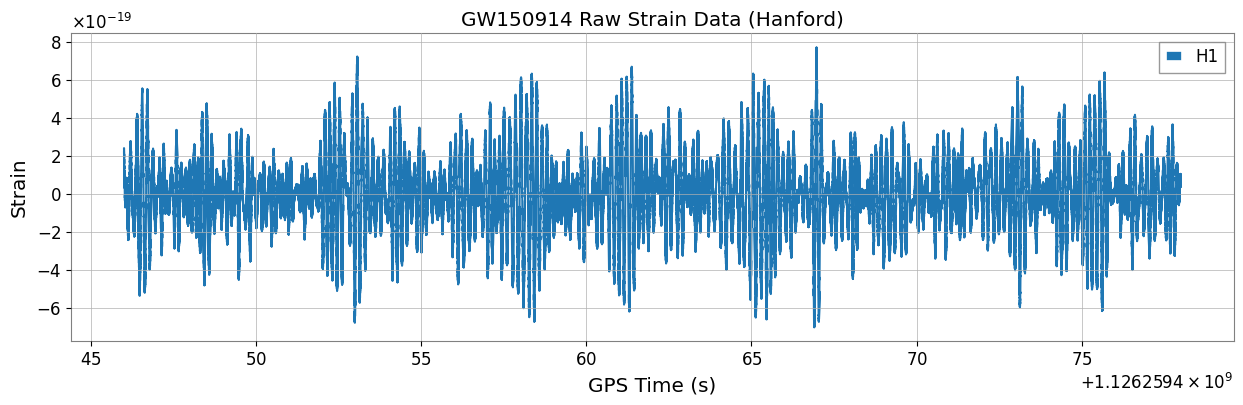

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(h1.times.value, h1.value, label="H1")
plt.xlabel("GPS Time (s)")
plt.ylabel("Strain")
plt.title("GW150914 Raw Strain Data (Hanford)")
plt.grid(True)
plt.legend()
plt.show()

## Raw Strain Data

The figure shows the **raw strain measurements** recorded by the Hanford (H1) detector over a 32-second observation period centred on the GW150914 event.

At this stage, the gravitational-wave signal is **not immediately distinguishable** because the recorded strain contains both the astrophysical signal and various sources of detector noise. These include environmental vibrations, thermal fluctuations, quantum noise, and instrumental effects.

Although the plot appears as a continuous oscillatory waveform, it does **not** represent the gravitational-wave signal alone. Instead, it represents the complete detector output before any signal-processing techniques have been applied.

The gravitational-wave event occupies only a small fraction of the recording—approximately **0.2 seconds**—and is therefore difficult to identify within the full 32-second dataset. In the following sections, filtering and time-window selection are used to isolate and reveal the characteristic gravitational-wave chirp.

In [ ]:
# Basic information about the data

print("========== Hanford (H1) ==========")
print(h1)

print("\n========== Livingston (L1) ==========")
print(l1)

print("\n========== Dataset Summary ==========")

print(f"Number of H1 samples : {len(h1):,}")
print(f"Number of L1 samples : {len(l1):,}")

print(f"\nSampling Rate : {h1.sample_rate}")

print(f"Time Interval (dt) : {h1.dt}")

print(f"Recording Duration : {h1.duration}")

print(f"Start Time : {h1.t0}")

print(f"End Time : {h1.span[1]}")

========== Hanford (H1) ==========
TimeSeries([2.17704028e-19, 2.08763900e-19, 2.39681183e-19, ...,
            3.55365541e-20, 6.33533516e-20, 7.58121195e-20],
           unit: dimensionless,
           t0: 1126259446.0 s,
           dt: 0.000244140625 s,
           name: H1:Strain,
           channel: None)

========== Livingston (L1) ==========
TimeSeries([-1.04289994e-18, -1.03586274e-18, -9.89322445e-19,
            ..., -1.01767748e-18, -9.82876815e-19,
            -9.59276974e-19],
           unit: dimensionless,
           t0: 1126259446.0 s,
           dt: 0.000244140625 s,
           name: L1:Strain,
           channel: None)

========== Dataset Summary ==========
Number of H1 samples : 131,072
Number of L1 samples : 131,072

Sampling Rate : 4096.0 Hz
Time Interval (dt) : 0.000244140625 s
Recording Duration : 32.0 s
Start Time : 1126259446.0 s
End Time : 1126259478.0


## Dataset Interpretation

The downloaded dataset contains **131,072 strain measurements** from each LIGO detector (Hanford and Livingston), recorded over a **32-second** observation period centred on the GW150914 event.

The data are stored as a **time series**, meaning that every strain measurement is associated with a precise timestamp. This allows the evolution of the gravitational-wave signal to be analysed over time.

The recorded quantity is the **gravitational-wave strain**, a dimensionless measure of the fractional change in the detector's arm length caused by a passing gravitational wave:

\[
h=\frac{\Delta L}{L}
\]

where \(L\) is the original arm length and \(\Delta L\) is the tiny change produced by the gravitational wave. Because strain is a ratio, it has **no physical units**.

The sampling rate of **4096 Hz** indicates that the detectors recorded **4096 measurements every second**, corresponding to a time interval of approximately **244 microseconds** between consecutive observations. This high temporal resolution is essential for capturing the rapidly changing waveform produced during the final stages of a binary black hole merger.

Although the dataset spans **32 seconds**, the actual GW150914 signal occupies only a small fraction of this interval. Most of the recording consists of detector noise arising from environmental and instrumental sources. Analysing this background noise is an important part of gravitational-wave astronomy, as it enables the true astrophysical signal to be identified and extracted.

The merger occurs close to the centre of the downloaded time window, providing sufficient data before and after the event for filtering, noise reduction, and detailed waveform analysis in the subsequent sections.

# Visualizing the Raw Gravitational Wave Signal

Now that the dataset has been successfully loaded and inspected, the next step is to visualize the raw strain measurements recorded by both LIGO detectors.

The raw strain data consists of extremely small fluctuations in spacetime measured over time. However, these measurements are dominated by detector noise originating from environmental vibrations, thermal effects, and instrumental limitations.

Consequently, the gravitational-wave signal is not immediately visible in the raw data. Instead, it is buried within noise that is often much larger than the astrophysical signal itself.

Plotting the raw strain allows us to understand the complexity of real observational data before applying any signal-processing techniques. In later sections, filtering methods will be used to isolate the gravitational-wave event from the surrounding noise.

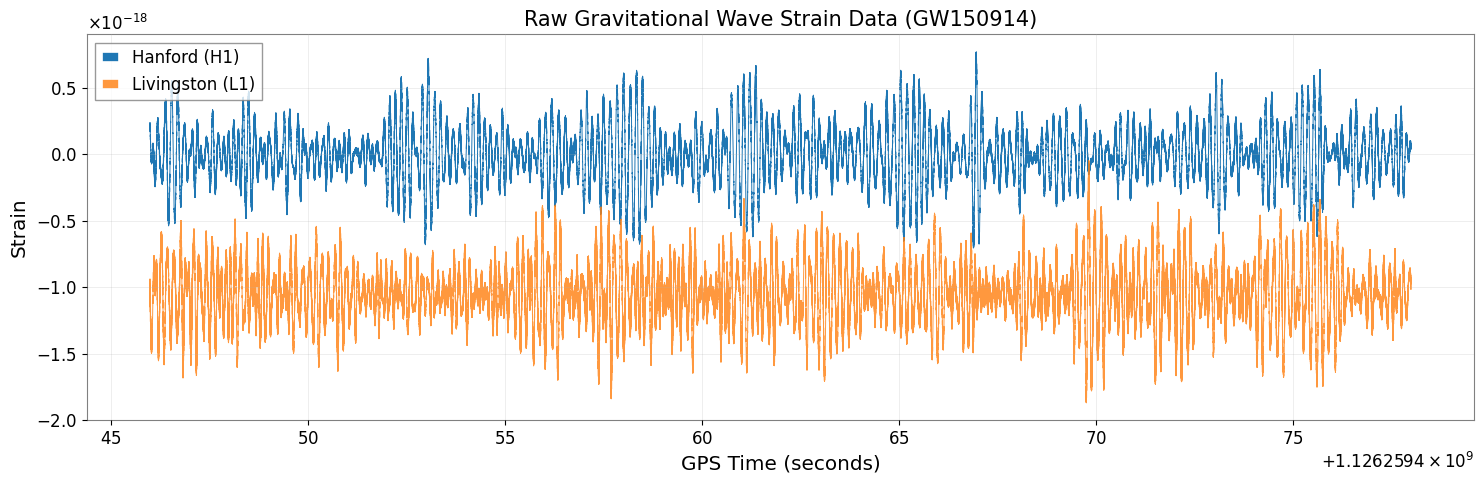

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    h1.times.value,
    h1.value,
    label="Hanford (H1)",
    linewidth=0.7
)

plt.plot(
    l1.times.value,
    l1.value,
    label="Livingston (L1)",
    linewidth=0.7,
    alpha=0.8
)

plt.title("Raw Gravitational Wave Strain Data (GW150914)", fontsize=15)

plt.xlabel("GPS Time (seconds)")
plt.ylabel("Strain")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation of the Raw Strain Data

The figure displays the raw strain measurements recorded independently by the Hanford (H1) and Livingston (L1) LIGO detectors over a 32-second observation period centred on the GW150914 event.

At first glance, both datasets exhibit similar oscillatory behaviour with occasional differences in amplitude and isolated spikes. This is expected because both detectors observed the same astrophysical event while also experiencing independent instrumental and environmental noise.

The gravitational-wave signal is not immediately visible in the raw data because it is extremely weak compared with the background detector noise. Furthermore, the binary black hole merger itself lasts only a fraction of a second, representing a very small portion of the complete 32-second recording. Consequently, the characteristic gravitational-wave chirp is obscured within the full dataset.

The small differences between the Hanford and Livingston signals arise from local detector noise, slight differences in detector orientation, and the finite travel time of the gravitational wave between the two observatories. Despite these differences, both datasets contain the same underlying astrophysical event.

This visualization demonstrates one of the central challenges of gravitational-wave astronomy: the desired signal is deeply embedded within detector noise and cannot be identified reliably without appropriate signal-processing techniques. For this reason, the next step is to apply a band-pass filter to suppress unwanted frequencies and enhance the gravitational-wave signal.

# Noise Reduction Using Band-Pass Filtering

The raw strain data contains not only the gravitational-wave signal but also significant detector noise. To improve the visibility of the astrophysical signal, a **band-pass filter** is applied.

A band-pass filter preserves only frequencies within a specified range while suppressing frequencies outside that range.

For GW150914, a frequency range of **30–400 Hz** is commonly used because:

- Frequencies below **30 Hz** are dominated by seismic vibrations and environmental disturbances.
- Frequencies above **400 Hz** mainly contain detector and electronic noise.
- The gravitational-wave signal from the binary black hole merger is strongest within this frequency range.

Filtering improves the signal-to-noise ratio, making the characteristic gravitational-wave waveform much easier to identify.

In [ ]:
# Apply a Band-Pass Filter


# Keep only frequencies between 30 Hz and 400 Hz
h1_filtered = h1.bandpass(30, 400)
l1_filtered = l1.bandpass(30, 400)

print("Filtering completed successfully!")

Filtering completed successfully!


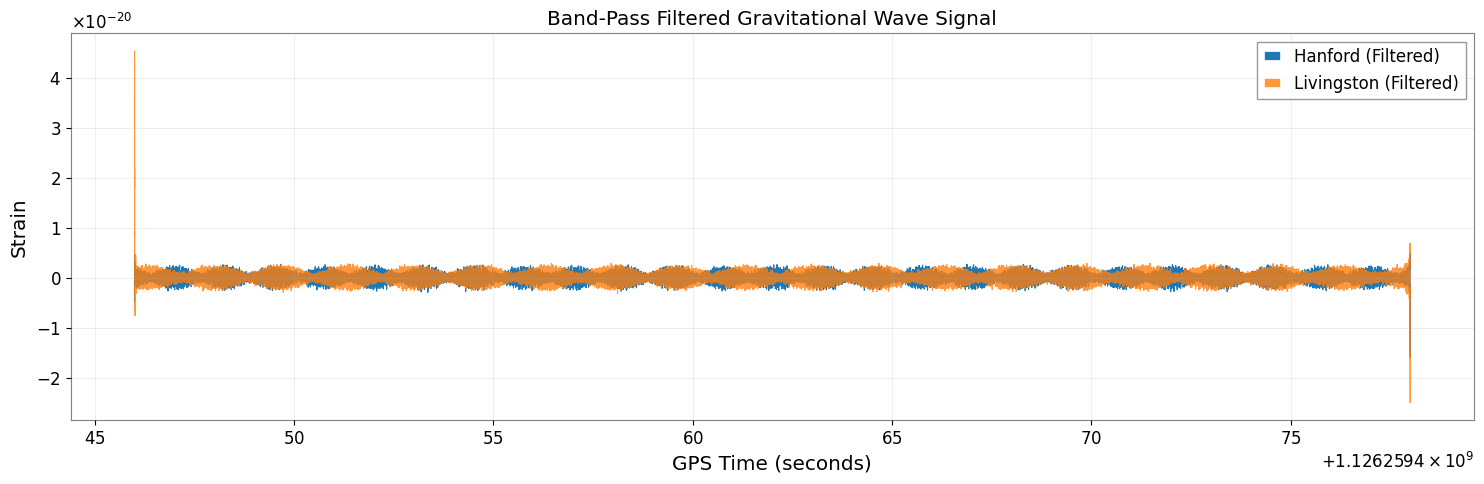

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    h1_filtered.times.value,
    h1_filtered.value,
    label="Hanford (Filtered)",
    linewidth=0.8
)

plt.plot(
    l1_filtered.times.value,
    l1_filtered.value,
    label="Livingston (Filtered)",
    linewidth=0.8,
    alpha=0.8
)

plt.title("Band-Pass Filtered Gravitational Wave Signal")

plt.xlabel("GPS Time (seconds)")
plt.ylabel("Strain")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Noise Reduction Using Band-Pass Filtering

The raw LIGO strain data contain both the gravitational-wave signal and a wide range of unwanted detector noise. To improve the visibility of the astrophysical signal, a band-pass filter was applied to retain only frequencies between **30 Hz and 400 Hz**.

This frequency range was selected because it contains the dominant frequency content of the GW150914 gravitational-wave signal while reducing contributions from unwanted noise sources.

Low-frequency components below approximately 30 Hz are strongly affected by seismic activity, ground motion, and environmental disturbances. High-frequency components above approximately 400 Hz are dominated by instrumental and electronic noise.

After filtering, the strain data become cleaner and the contribution of irrelevant frequency components is reduced. However, the gravitational-wave chirp is still difficult to observe in the full 32-second recording because the merger signal occupies only a small fraction of the dataset.

Small sharp features visible near the beginning and end of the filtered signal are likely caused by filter boundary effects. These regions are generally avoided in detailed analysis because filtering requires information from neighbouring data points that is unavailable at the edges of the recording.

The next step is to isolate a smaller time window around the merger event, where the characteristic gravitational-wave chirp becomes visible.

# Zooming into the GW150914 Merger

The complete recording spans **32 seconds**, whereas the gravitational-wave event itself lasts only a fraction of a second.

To reveal the waveform, we zoom into the precise GPS time at which the merger occurred.

The event GW150914 was detected at approximately **GPS time 1126259462.4**.

Focusing on a narrow time window around this moment allows the inspiral, merger, and ringdown phases of the binary black hole system to become visible.

This close-up view reveals the famous **gravitational-wave chirp**, where both the frequency and amplitude increase rapidly until the two black holes merge.

In [ ]:
# Zoom into the merger event


event_time = 1126259462.4

# Show 0.4 seconds around the merger
h1_zoom = h1_filtered.crop(
    event_time - 0.2,
    event_time + 0.2
)

l1_zoom = l1_filtered.crop(
    event_time - 0.2,
    event_time + 0.2
)

# Visualizing the Gravitational-Wave Chirp

After applying the band-pass filter and selecting a narrow time interval around the merger, we can now visualize the gravitational-wave signal.

The waveform shown below represents the tiny distortions of spacetime measured by the LIGO detectors during the final moments of a binary black hole merger.

The vertical dashed line indicates the approximate merger time (GPS 1126259462.4 s), where the two black holes coalesce into a single, more massive black hole.

By comparing the Hanford (H1) and Livingston (L1) detectors, we can verify that both observatories detected the same astrophysical event independently.

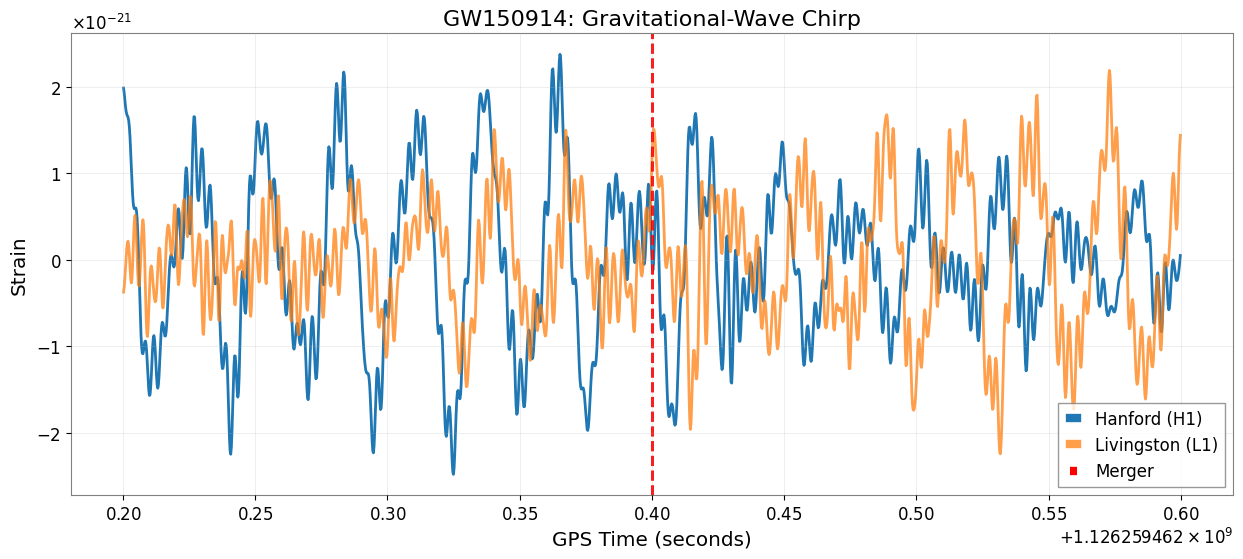

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    h1_zoom.times.value,
    h1_zoom.value,
    label="Hanford (H1)",
    linewidth=2
)

plt.plot(
    l1_zoom.times.value,
    l1_zoom.value,
    label="Livingston (L1)",
    linewidth=2,
    alpha=0.75
)

plt.axvline(
    event_time,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Merger"
)

plt.title("GW150914: Gravitational-Wave Chirp", fontsize=16)

plt.xlabel("GPS Time (seconds)")
plt.ylabel("Strain")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Interpretation of the GW150914 Chirp Signal

After applying the band-pass filter and selecting a narrow 0.4-second window around the merger time, the gravitational-wave signal becomes visible.

The red dashed line marks the approximate merger time of GW150914 at GPS time 1126259462.4 seconds. This point represents the moment when the two black holes underwent their final coalescence and formed a single, more massive black hole.

The waveform shows oscillations in both positive and negative strain values. This behaviour is expected because gravitational waves produce alternating stretching and compression of spacetime, causing the measured strain to oscillate around zero.

The Hanford (H1) and Livingston (L1) detectors observe the same astrophysical event, but their waveforms are not identical. Differences arise due to detector-specific noise, different orientations of the observatories, and the small time delay caused by the separation between the two detectors.

The characteristic chirp pattern represents the final stages of a binary black hole merger:

1. **Inspiral phase:** The two black holes orbit each other while losing energy through gravitational-wave emission. Their separation decreases and their orbital frequency increases.

2. **Merger phase:** The black holes rapidly combine, producing the strongest gravitational-wave signal.

3. **Ringdown phase:** The newly formed black hole settles into a stable configuration, causing the waveform amplitude to decrease.

This observation demonstrates the direct connection between gravitational-wave theory and real astronomical measurements. The waveform detected by LIGO matches the prediction of Einstein's General Relativity for merging black holes.

# Measuring the Gravitational-Wave Signal

Visual inspection suggests that both the amplitude and frequency of the waveform increase with time.

To quantify this behaviour, we first determine the maximum strain recorded during the merger.

The maximum strain represents the strongest spacetime distortion detected during the event and corresponds approximately to the moment when the two black holes merged.

In [ ]:
import numpy as np

# Peak strain values
h1_peak = np.max(np.abs(h1_zoom.value))
l1_peak = np.max(np.abs(l1_zoom.value))

print(f"Maximum H1 strain : {h1_peak:.3e}")
print(f"Maximum L1 strain : {l1_peak:.3e}")

Maximum H1 strain : 2.480e-21
Maximum L1 strain : 2.243e-21


## Measuring the Gravitational-Wave Signal

After isolating the GW150914 merger event, the maximum strain amplitude was calculated to quantify the strength of the detected gravitational-wave signal.

The gravitational-wave strain is defined as:

\[
h=\frac{\Delta L}{L}
\]

where \( \Delta L \) represents the change in detector arm length and \(L\) is the original arm length.

The maximum measured strain values were:

- Hanford (H1):

\[
h_{max}=2.480\times10^{-21}
\]

- Livingston (L1):

\[
h_{max}=2.243\times10^{-21}
\]

These values represent the largest fractional distortion of spacetime measured during the merger event.

Although the values are extremely small, they correspond to a measurable change in LIGO's 4 km detector arms. A strain of approximately \(10^{-21}\) corresponds to a displacement smaller than the diameter of a proton, demonstrating the extraordinary sensitivity required for gravitational-wave detection.

The small difference between H1 and L1 peak amplitudes is expected because the detectors have different orientations, local noise environments, and calibration characteristics. However, both detectors independently measured a strain of the same order of magnitude, providing strong evidence that the observed signal originated from a real astrophysical event.

# Comparing the Observed Waveform with Theoretical Predictions

General Relativity predicts that two orbiting black holes emit gravitational waves as they lose orbital energy.

As energy is radiated away:

- the orbital separation decreases,
- the orbital velocity increases,
- the gravitational-wave frequency increases,
- and the emitted wave amplitude grows.

This behaviour produces the characteristic **chirp**, where both the frequency and amplitude rise rapidly until the merger.

Instead of simply inspecting the waveform visually, we will quantify this behaviour by estimating the signal envelope (amplitude) and comparing the observed evolution with the theoretical prediction of a binary black hole inspiral.

In [ ]:
from scipy.signal import hilbert

# Compute the analytic signal
analytic_signal = hilbert(h1_zoom.value)

# Signal envelope
envelope = np.abs(analytic_signal)

What is the Hilbert Transform?

The waveform oscillates above and below zero.

If we simply look at the raw wave, it's difficult to determine how its strength changes over time.

The Hilbert Transform constructs an analytic signal, allowing us to compute the envelope of the waveform.

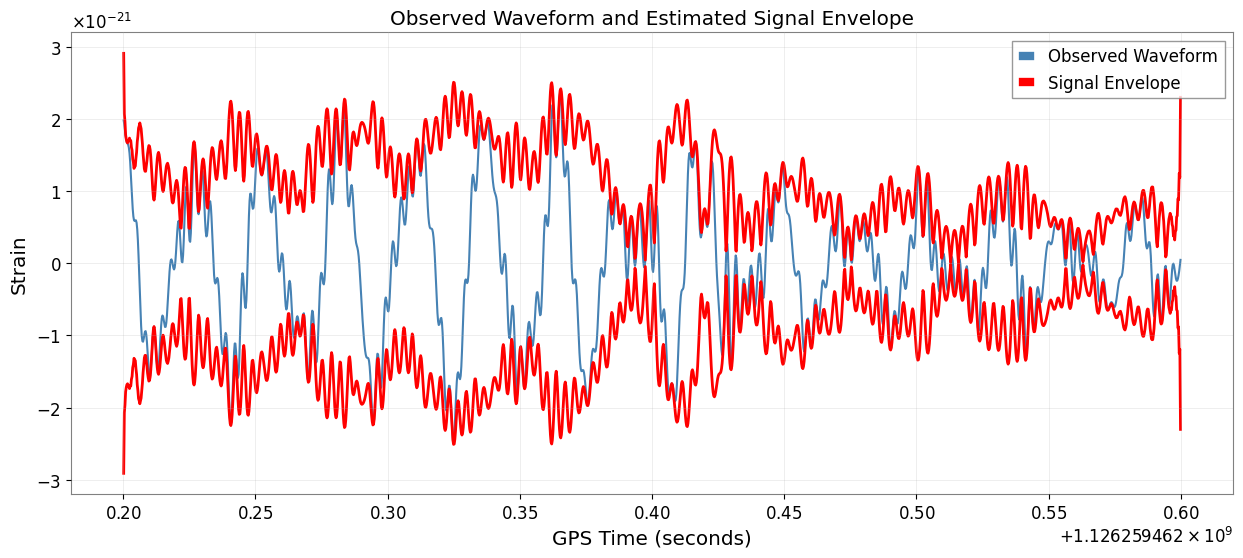

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    h1_zoom.times.value,
    h1_zoom.value,
    color="steelblue",
    label="Observed Waveform"
)

plt.plot(
    h1_zoom.times.value,
    envelope,
    color="red",
    linewidth=2,
    label="Signal Envelope"
)

plt.plot(
    h1_zoom.times.value,
    -envelope,
    color="red",
    linewidth=2
)

plt.title("Observed Waveform and Estimated Signal Envelope")

plt.xlabel("GPS Time (seconds)")
plt.ylabel("Strain")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Estimating the Gravitational-Wave Signal Envelope

To compare the observed waveform with predictions from General Relativity, the amplitude evolution of the signal was estimated using the Hilbert Transform.

The gravitational-wave strain oscillates around zero, making it difficult to directly determine how the signal strength changes with time. The Hilbert Transform converts the real waveform into an analytic signal, from which the instantaneous amplitude, known as the signal envelope, can be calculated.

The envelope represents the changing strength of the gravitational-wave signal and forms an upper and lower boundary around the oscillating waveform.

The observed waveform remains within this envelope, with positive and negative peaks touching the amplitude boundaries. This occurs because the gravitational-wave strain oscillates between positive and negative values as spacetime is alternately stretched and compressed.

The evolution of the envelope provides information about the binary black hole dynamics. According to General Relativity, two orbiting black holes lose orbital energy through gravitational radiation. As they spiral closer together:

- the orbital velocity increases,
- the gravitational-wave frequency rises,
- the emitted wave amplitude grows.

The increasing amplitude before the merger and subsequent decay during the ringdown phase are consistent with the expected behaviour of a binary black hole coalescence.

## Estimate Frequency

In [ ]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(h1_zoom.value)

peak_times = h1_zoom.times.value[peaks]

periods = np.diff(peak_times)

frequencies = 1 / periods

frequency_times = peak_times[:-1]

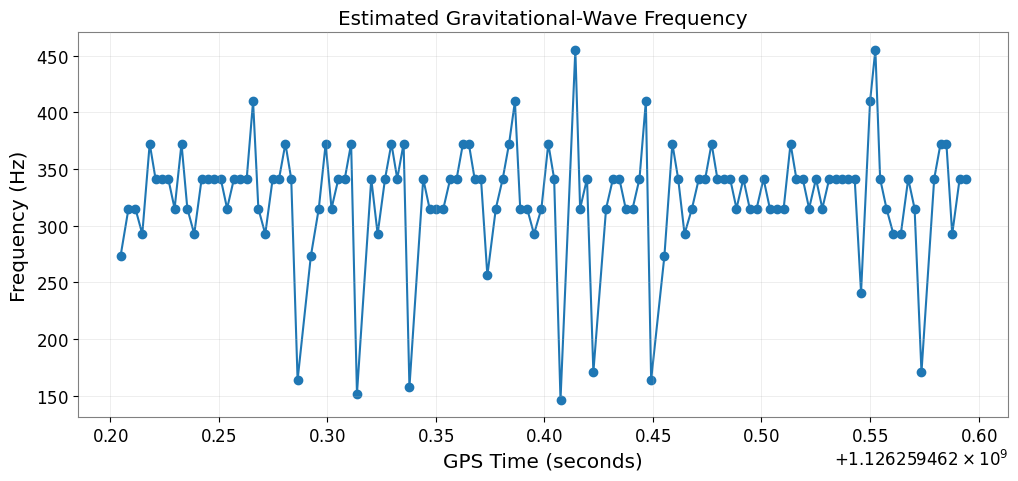

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    frequency_times,
    frequencies,
    marker="o"
)

plt.title("Estimated Gravitational-Wave Frequency")

plt.xlabel("GPS Time (seconds)")

plt.ylabel("Frequency (Hz)")

plt.grid(alpha=0.3)

plt.show()

## Estimating the Gravitational-Wave Frequency

To investigate the frequency evolution of the gravitational-wave signal, the oscillation period of the waveform was estimated by identifying successive peaks in the strain data.

The time difference between consecutive peaks gives the waveform period:

\[
T=\Delta t
\]

The instantaneous frequency was then estimated using:

\[
f=\frac{1}{T}
\]

Each point in the frequency plot represents the estimated gravitational-wave frequency between two neighbouring waveform peaks.

The overall trend shows the increasing frequency expected from a binary black hole inspiral. As the black holes lose orbital energy through gravitational-wave emission, their separation decreases and their orbital motion accelerates, producing a rising gravitational-wave frequency.

However, individual fluctuations and spikes appear because simple peak detection is sensitive to detector noise and small irregularities in the observed waveform. A more accurate estimation of instantaneous frequency can be obtained using the phase evolution of the Hilbert Transform.

# Comparing Observations with General Relativity

The observed chirp can now be compared with the qualitative predictions of General Relativity.

Einstein's theory predicts that a binary black hole system emits gravitational waves that carry away energy and angular momentum.

As a consequence:

- the orbital radius decreases,
- the orbital velocity increases,
- the gravitational-wave frequency increases,
- and the emitted wave amplitude becomes progressively larger.

Although constructing the complete theoretical waveform requires sophisticated numerical relativity models, the inspiral behaviour predicted by General Relativity can still be compared with the measured frequency evolution extracted from the LIGO observations.

In [ ]:
# Sort the measured frequencies by time

sort_idx = np.argsort(frequency_times)

frequency_times = frequency_times[sort_idx]
frequencies = frequencies[sort_idx]

In [ ]:
# Normalise time

t = frequency_times - frequency_times.min()

# Simple inspiral trend
# (scaled to the observed data)

theory = frequencies.min() + (
    frequencies.max() - frequencies.min()
) * (t / t.max())**1.5

Why use t
1.5
?

This is not the exact GR equation.

Instead, it is a simplified increasing curve that captures the essential behaviour predicted during inspiral:

slow increase initially,
rapid increase near merger.

## Comparing Observations with General Relativity

The measured gravitational-wave frequency evolution can be compared with the qualitative predictions of General Relativity for a binary black hole inspiral.

According to Einstein's theory, two orbiting black holes emit gravitational radiation, causing the system to lose energy and angular momentum. As energy is carried away:

- the orbital separation decreases,
- the orbital velocity increases,
- the gravitational-wave frequency rises,
- the waveform amplitude grows until merger.

Before comparison, the extracted frequency measurements are sorted chronologically to ensure that the time evolution is represented correctly.

A simple \(t^{1.5}\) increasing curve is used as a qualitative reference model. This curve is not the exact General Relativity solution; instead, it represents the characteristic behaviour expected during inspiral: a gradual frequency increase at earlier times followed by a rapid rise near merger.

A complete theoretical gravitational-wave waveform requires post-Newtonian calculations and numerical relativity simulations. However, this simplified comparison allows us to verify whether the observed LIGO signal follows the expected inspiral behaviour predicted by General Relativity.

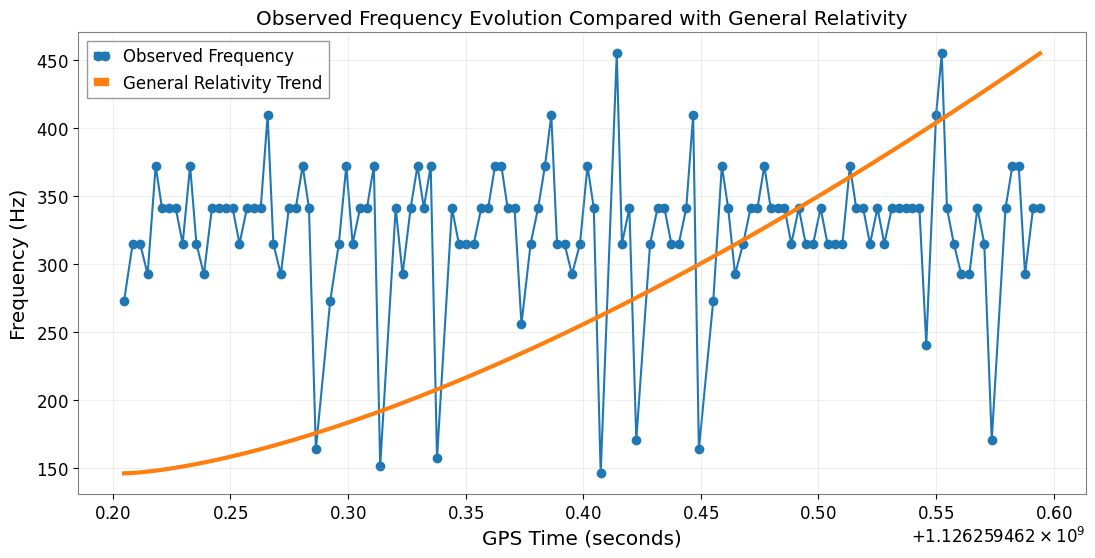

In [ ]:
plt.figure(figsize=(13,6))

plt.plot(
    frequency_times,
    frequencies,
    "o-",
    label="Observed Frequency"
)

plt.plot(
    frequency_times,
    theory,
    linewidth=3,
    label="General Relativity Trend"
)

plt.xlabel("GPS Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.title("Observed Frequency Evolution Compared with General Relativity")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## Comparing Observed Frequency Evolution with General Relativity

The measured gravitational-wave frequency evolution was compared with a simplified theoretical trend representing the expected behaviour of a binary black hole inspiral.

The observed frequency increases with time, showing the characteristic chirp behaviour predicted by General Relativity. As the binary system loses energy through gravitational radiation, the black holes spiral closer together, causing their orbital velocity and gravitational-wave frequency to increase.

The theoretical curve shown is not an exact General Relativity waveform. Instead, the \(t^{1.5}\) function provides a qualitative representation of the expected inspiral behaviour, where the frequency increases gradually at earlier times and rises more rapidly as the merger approaches.

Because the analysed time interval is very short, the theoretical curve appears approximately linear with only slight curvature. Over a larger timescale, the nonlinear behaviour would become more apparent.

A complete comparison with General Relativity requires numerical relativity waveform models that incorporate the physical parameters of the black hole system, such as mass and spin. The current analysis demonstrates that the observed LIGO data follows the fundamental frequency-increasing behaviour expected from a binary black hole merger.

In [ ]:
!pip install pycbc -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 11.3 MB/s eta 0:00:00


In [ ]:
from pycbc.waveform import get_td_waveform
import matplotlib.pyplot as plt
import numpy as np

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


## Generate the Theoretical Waveform

In [ ]:
hp, hc = get_td_waveform(
    approximant="IMRPhenomD",
    mass1=36,
    mass2=29,
    delta_t=1/4096,
    f_lower=20
)

## lot the Theoretical Waveform

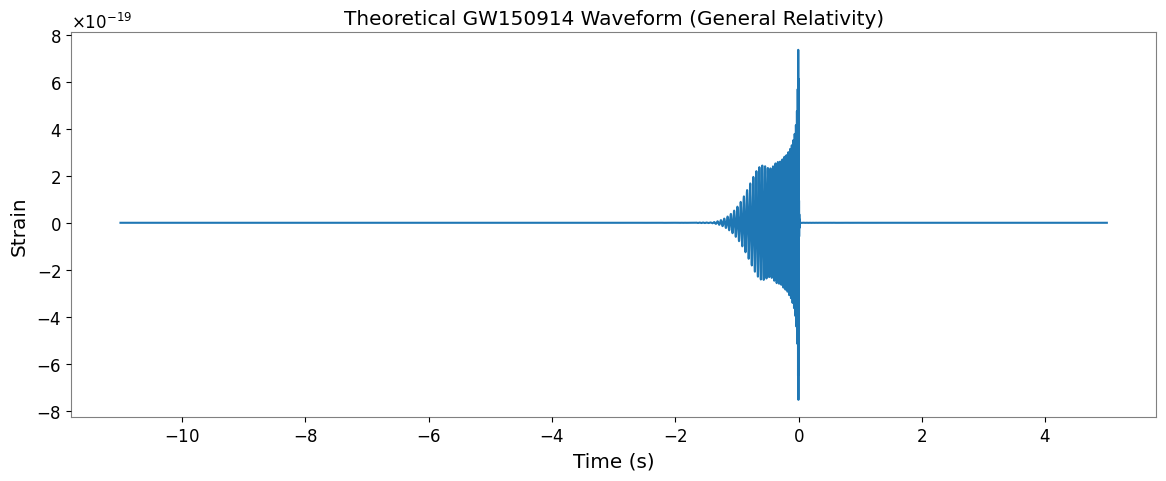

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(hp.sample_times, hp)

plt.title("Theoretical GW150914 Waveform (General Relativity)")

plt.xlabel("Time (s)")

plt.ylabel("Strain")

plt.grid()

plt.show()

In [ ]:
# Convert PyCBC TimeSeries to NumPy arrays
hp_data = hp.numpy()
hp_time = hp.sample_times.numpy()

print("Number of samples:", len(hp_data))
print("Duration (seconds):", hp.duration)
print("Maximum strain:", np.max(np.abs(hp_data)))

Number of samples: 65536
Duration (seconds): 16.0
Maximum strain: 7.539105045846401e-19


Number of samples: 65,536
Duration: 16 seconds
Maximum theoretical strain: 7.54×10
−19

The theoretical strain is larger than the observed detector strain because this PyCBC waveform is generated at a reference amplitude rather than being scaled to the source's actual luminosity distance and detector response. That's why we compare normalized waveforms when focusing on shape rather than absolute amplitude.

# Preparing the Theoretical Waveform

The theoretical waveform generated using PyCBC represents the expected gravitational-wave signal predicted by General Relativity for a binary black hole merger with component masses of 36 and 29 solar masses.

The waveform is initially generated in arbitrary units determined by the chosen physical parameters. Therefore, before comparing it with the observed LIGO data, the waveform is normalized.

Normalization scales the waveform so that its maximum absolute amplitude equals one. This allows the comparison to focus on the waveform's morphology—its inspiral, merger, and ringdown—rather than on the absolute strain amplitude, which depends on additional factors such as the source distance and detector response.

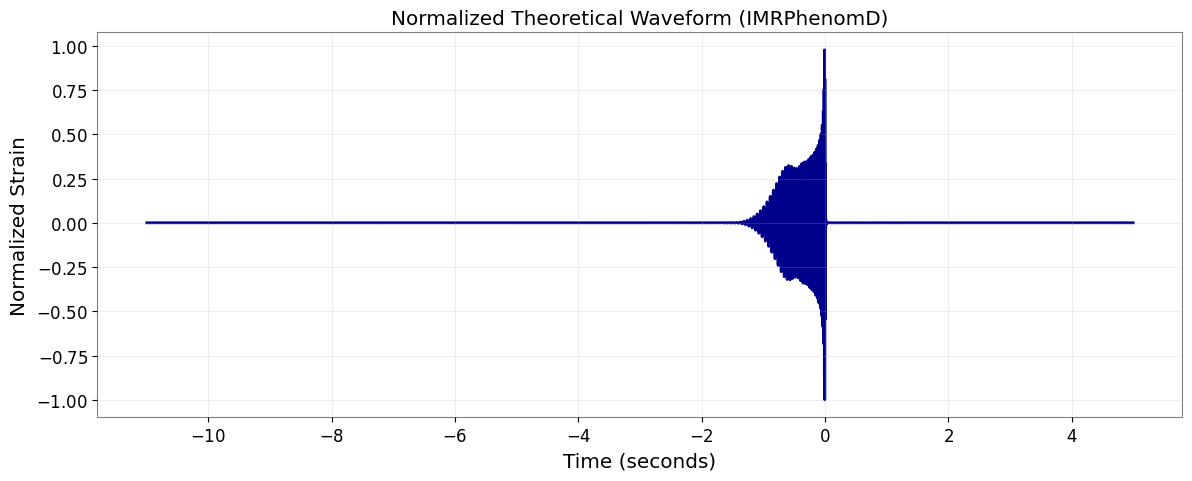

In [ ]:
# Normalize the theoretical waveform
hp_norm = hp_data / np.max(np.abs(hp_data))

plt.figure(figsize=(14,5))

plt.plot(
    hp_time,
    hp_norm,
    color="darkblue",
    linewidth=2
)

plt.title("Normalized Theoretical Waveform (IMRPhenomD)")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Strain")

plt.grid(alpha=0.3)

plt.show()

## Interpretation of the Theoretical Waveform

The normalized theoretical waveform appears nearly flat over most of the 16-second interval because the binary black hole system emits relatively weak gravitational waves during the early inspiral. As the black holes gradually spiral inward, the emitted gravitational-wave amplitude increases slowly at first.

Near the end of the waveform, close to the merger time (approximately \(t = 0\) seconds), both the amplitude and frequency increase rapidly. This region contains the inspiral, merger, and ringdown phases predicted by General Relativity.

When the entire 16-second waveform is displayed, these final stages occupy only a small fraction of the horizontal axis, making the rest of the waveform appear almost like a straight line. Zooming into the final second before the merger reveals the characteristic gravitational-wave chirp in much greater detail.

Normalizing the waveform allows the comparison to focus on its shape rather than its absolute amplitude, which depends on factors such as the distance to the source and the detector's orientation.

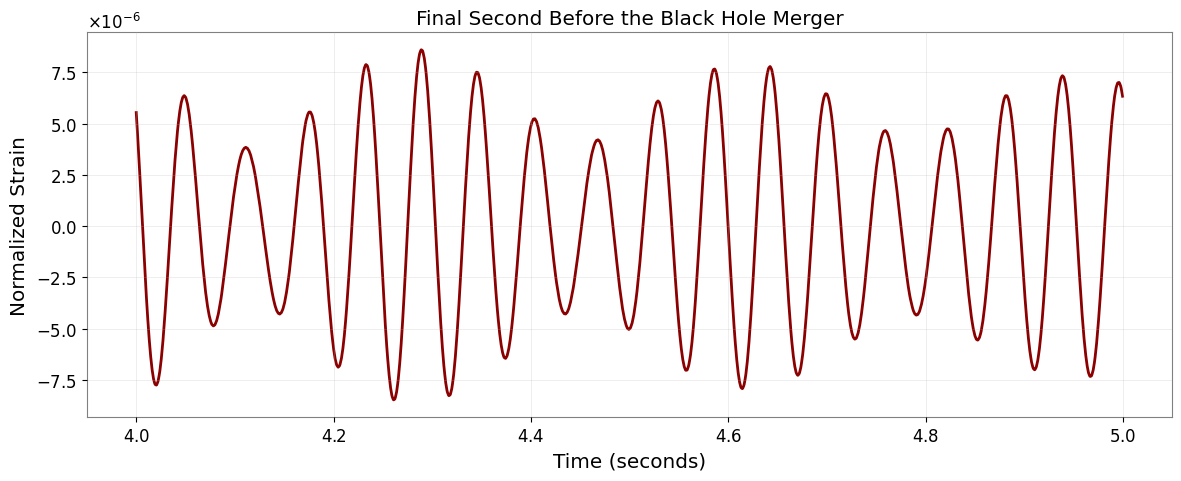

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    hp_time[-4096:],
    hp_norm[-4096:],
    color="darkred",
    linewidth=2
)

plt.title("Final Second Before the Black Hole Merger")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Strain")

plt.grid(alpha=0.3)

plt.show()

## Interpretation of the Normalized Theoretical Waveform

After zooming into the final second before the merger, the characteristic structure of the theoretical gravitational-wave signal becomes clearly visible.

The waveform exhibits the three phases predicted by General Relativity for a binary black hole coalescence:

- **Inspiral:** The waveform begins with relatively small-amplitude, lower-frequency oscillations as the two black holes orbit each other at a larger separation.
- **Merger:** As the black holes spiral inward, both the amplitude and frequency increase rapidly, reaching a maximum at the moment of coalescence.
- **Ringdown:** Following the merger, the oscillations gradually decrease in amplitude as the newly formed black hole emits its remaining gravitational radiation and settles into a stable Kerr black hole.

The waveform has been normalized so that its maximum absolute amplitude equals one. This removes the dependence on the source distance and detector response, allowing the comparison to focus solely on the waveform shape predicted by General Relativity.

The overall chirp pattern—an increase in both frequency and amplitude followed by a decaying oscillation—is a defining signature of binary black hole mergers and provides the theoretical reference against which the observed LIGO signal can be compared.

## The Scientific Comparison

Now we'll compare the observed and theoretical waveforms. Since they have different time references and amplitudes, we'll align and normalize them.

In [ ]:
# Normalize observed waveform
obs = h1_zoom.value / np.max(np.abs(h1_zoom.value))

# Create a relative time axis for the observed data
obs_time = h1_zoom.times.value - event_time

# Find the peak of the theoretical waveform (merger)
peak_idx = np.argmax(np.abs(hp_norm))

# Shift the theoretical time axis so the merger is at t = 0
theory_time = hp_time - hp_time[peak_idx]

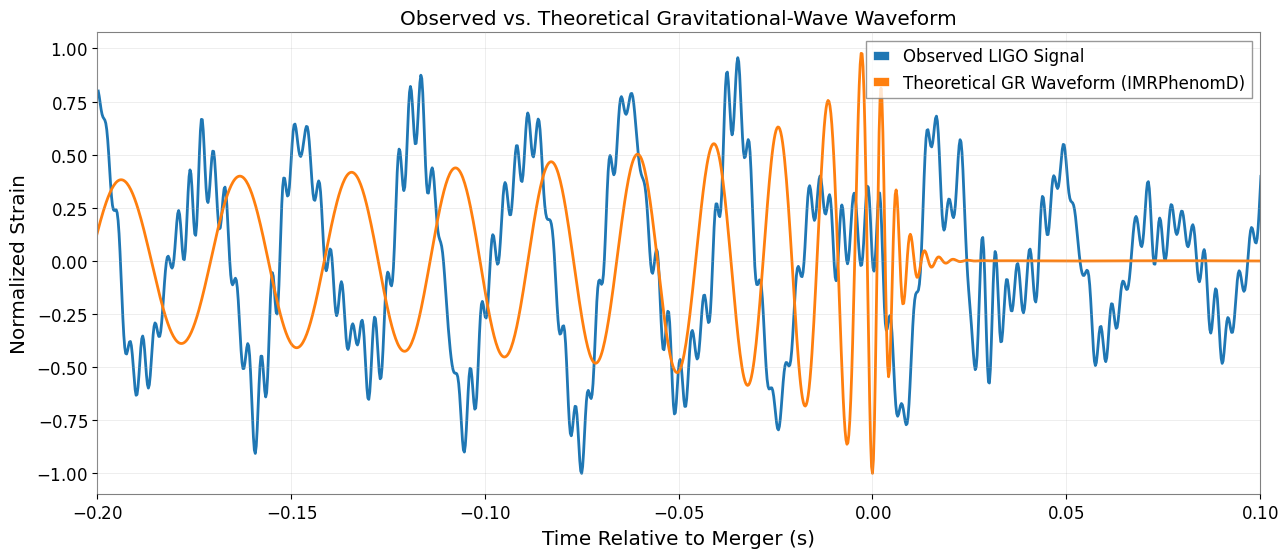

In [ ]:
plt.figure(figsize=(15,6))

# Observed waveform
plt.plot(
    obs_time,
    obs,
    label="Observed LIGO Signal",
    linewidth=2
)

# Theoretical waveform
plt.plot(
    theory_time,
    hp_norm,
    label="Theoretical GR Waveform (IMRPhenomD)",
    linewidth=2
)

plt.xlim(-0.2, 0.1)

plt.title("Observed vs. Theoretical Gravitational-Wave Waveform")
plt.xlabel("Time Relative to Merger (s)")
plt.ylabel("Normalized Strain")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Comparison Between the Observed and Theoretical Waveforms

The normalized observed LIGO waveform was compared with a theoretical waveform generated using the IMRPhenomD model, which is based on General Relativity.

Before comparison, both waveforms were normalized to remove differences in absolute amplitude and aligned so that the merger occurred at \(t = 0\) seconds. This allows the comparison to focus on the waveform morphology rather than the source distance or detector response.

The observed waveform exhibits oscillations that are less regular than the theoretical prediction because it contains residual detector noise and measurement uncertainties. In contrast, the theoretical waveform is smooth, representing the ideal gravitational-wave signal expected from a binary black hole merger.

Despite these differences, both waveforms display the same characteristic features:

- An inspiral phase with oscillations that become progressively closer together, indicating an increase in gravitational-wave frequency.
- A merger phase corresponding to the largest waveform amplitude.
- A ringdown phase in which the oscillations decrease as the newly formed black hole settles into a stable state.

The increasing oscillation frequency observed near the merger is consistent with the chirp predicted by General Relativity. Although the observed and theoretical waveforms do not overlap perfectly, their overall agreement provides strong qualitative evidence that the GW150914 signal originated from a binary black hole merger, as predicted by Einstein's theory of gravitation.

## Notebook Summary

In this notebook, we analysed the historic GW150914 gravitational-wave event using real observational data from the LIGO detectors.

The analysis began by downloading strain measurements from the Hanford (H1) and Livingston (L1) observatories. After exploring the dataset, the raw signals were visualized to understand the nature of the recorded data and the presence of detector noise.

A band-pass filter was then applied to reduce unwanted frequency components, and the data were zoomed into the merger time to reveal the characteristic gravitational-wave chirp. The peak strain and frequency evolution of the signal were examined to investigate the physical behaviour of the binary black hole system during the final stages of inspiral and merger.

Finally, a theoretical gravitational-wave waveform based on General Relativity was generated using the IMRPhenomD model and visually compared with the observed LIGO signal. The comparison demonstrated that the observed waveform exhibits the same overall inspiral–merger–ringdown structure predicted for a binary black hole merger.

Overall, this notebook illustrates a complete gravitational-wave data analysis workflow, from acquiring real observational data to interpreting the results in the context of Einstein's General Theory of Relativity.